# Chapter 1: Workload and Performance

Research Question: Does increasing time pressure lead to worse human performance? Can this phenomenon be explained by a simple speed-accuracy trade-off, or does it trigger a severe cognitive overload?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set clean graphic style
sns.set_theme(style="whitegrid")

# Load the dataset
df = pd.read_csv("../data/human_performance_dataset.csv")

In [2]:
df['time_pressure'].value_counts().sort_index()

time_pressure
high      114085
low       717508
medium    143832
Name: count, dtype: int64

In [3]:
df['trajectory_id'].nunique()

140

In [4]:
df.groupby('trajectory_id').size().describe()

count     140.000000
mean     6967.321429
std       114.669012
min      6357.000000
25%      7001.000000
50%      7001.000000
75%      7001.000000
max      7001.000000
dtype: float64

Sample Audit: We have 140 unique agents. The cross-check confirms that every agent was exposed to all three time pressure levels (low, medium, high). This ensures a perfectly balanced experimental design for a within-subject analysis.

### 1.1 Impact on Error Rate and Reaction Times
Let's start the exploration by visually mapping the distributions to identify any performance breakdowns or anomalies.

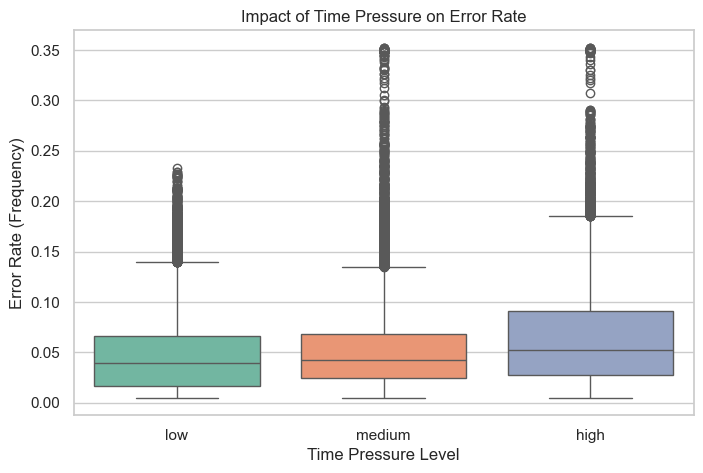

In [5]:
# Set figure size
plt.figure(figsize=(8, 5))

# Create boxplot crossing time pressure and error rate
sns.boxplot(data=df, x='time_pressure', y='error_rate', hue='time_pressure', palette='Set2', legend=False)

# Add title and axis labels
plt.title("Impact of Time Pressure on Error Rate")
plt.xlabel("Time Pressure Level")
plt.ylabel("Error Rate (Frequency)")

# Display the plot
plt.show()

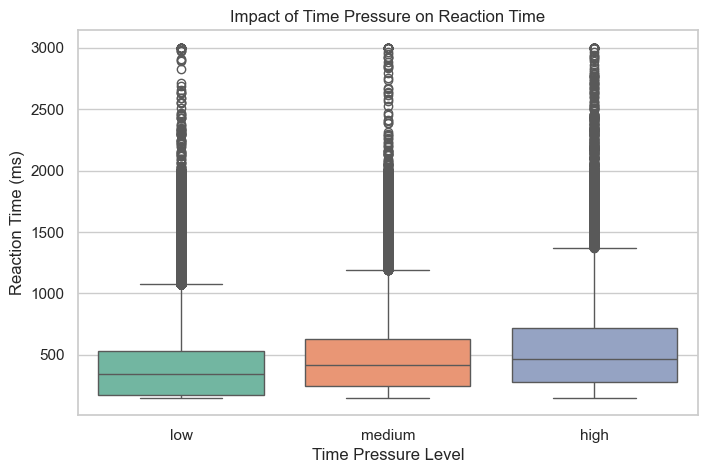

In [6]:
# Set figure size
plt.figure(figsize=(8, 5))

# Create boxplot crossing time pressure and reaction time
sns.boxplot(
    data=df, 
    x='time_pressure', 
    y='reaction_time', 
    hue='time_pressure', 
    palette='Set2', 
    legend= False
)

# Add title and axis labels
plt.title("Impact of Time Pressure on Reaction Time")
plt.xlabel("Time Pressure Level")
plt.ylabel("Reaction Time (ms)")

# Display the plot
plt.show()

*Visual Observations:* Contrary to the speed-accuracy trade-off hypothesis, the plots show that under high pressure, both errors and reaction times increase. The variance explosion and the density of outliers (reaction times up to 3000 ms) suggest a collapse of executive functions (freezing).

In [7]:
df.groupby('time_pressure')[['error_rate', 'reaction_time']].agg(
    ['mean', 'median', 'std'])

error_rate                     reaction_time              \
                    mean    median       std          mean      median   
time_pressure                                                            
high            0.061348  0.052137  0.041270    539.222143  468.660403   
low             0.045905  0.039738  0.032370    402.867441  339.808379   
medium          0.050429  0.042931  0.034921    479.639769  416.399732   

                           
                      std  
time_pressure              
high           343.941354  
low            266.929580  
medium         305.381385

### 1.2 Within-Subject Analysis (Low vs High Pressure)
Aggregated data shows a general performance decline, but is the stress response universal? Let's track the error rate variation for each individual agent when transitioning from low to high pressure.

In [8]:
agent_pressure = (df.groupby(['trajectory_id', 'time_pressure'])['error_rate'].mean().unstack())

agent_pressure.head()

time_pressure,high,low,medium
trajectory_id,,,
0,0.041000,0.043642,0.040956
1,0.015201,0.021800,0.015596
2,0.060074,0.048426,0.060077
3,0.049130,0.054361,0.050568
4,0.041533,0.038529,0.040391


In [9]:
agent_pressure['change_high_low'] = (
    agent_pressure['high'] - agent_pressure['low']
)

agent_pressure['change_high_low'].describe()

count    140.000000
mean       0.002562
std        0.012473
min       -0.011179
25%       -0.005083
50%       -0.000885
75%        0.004100
max        0.057509
Name: change_high_low, dtype: float64

In [10]:
(agent_pressure['change_high_low'] > 0).sum()

65

In [11]:
(agent_pressure['change_high_low'] < 0).sum()

75

Chapter 1 Conclusions:
The analysis reveals a phenomenon of performance polarization. While macroscopically time pressure generates a severe cognitive overload (dilated reaction times and critical errors), at the individual level we discover that 75 agents (out of 140) managed to maintain or improve their accuracy, while 65 experienced a performance breakdown. This suggests that time pressure alone cannot fully explain task failure: attentional resources and stress coping mechanisms vary significantly across subjects.